# Know Sure Thing — a quantitative teardown 🔬
### KST/signal long-flat (and long-short) timing on SPY · NET excess-vs-excess Sharpe race vs buy-and-hold / SMA-200 / MACD · HAC *t* · a sign-flip permutation placebo · cost sweep · one-day execution lag · a synthetic planted-trend control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_sure_thing%3F: Busted](https://img.shields.io/badge/A_sure_thing%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). KST is a weighted sum of four SMA-smoothed ROCs with a signal-line crossover rule. The job here is to ask the only question that matters for a *more complicated* indicator: **does it beat the obvious simpler benchmarks**, net of costs, on the real tape?

> ⚠️ **Data note.** SPY daily, yfinance auto-adjusted (**total return**), 1993-01-29→2026-06-23 (as-of the last fully-closed session; the in-progress bar is dropped). One-way cost × NAV, one execution lag, **excess-of-cash** Sharpe both sides. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from know_sure_thing import data, strategy as st

ASOF = "2026-06-23"   # last fully-closed session; drop the in-progress bar
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    BARS = data.load_real("SPY").loc[:ASOF]
    print("SPY cache present | bars:", len(BARS), "|",
          BARS.index.min().date(), "->", BARS.index.max().date(),
          "| fingerprint:", data.fingerprint(BARS))
else:
    BARS = None
    print("SPY cache present:", HAVE_REAL, "(quoting frozen R)")

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '1993-01-29', 'end': '2026-06-23', 'years': 33.4, 'n_bars': 8406, 'fp': 'b7fff1b5e020', 'cost_bps': 1.0, 'kst': (0.445, 4.29, -26.1, 2.65, 0.47, 458, 13.7), 'bah': (0.643, 10.76, -55.2, 4.33, 1.0, 1, 0.0), 'sma200': (0.727, 8.32, -28.3, 4.51, 0.75, 215, 6.4), 'macd': (0.421, 4.11, -38.5, 2.63, 0.5, 712, 21.3), 'perm_obs': 0.458, 'perm_p': 0.0044, 'spread_yr': -7.16, 'spread_t': -3.31, 'sweep': [(0.0, 0.458, 0.643), (1.0, 0.445, 0.643), (2.0, 0.432, 0.643), (5.0, 0.394, 0.643)], 'ls': (-0.139, -4.22, -81.4, -0.9), 'syn': [(0.0, 0.591, 0.732, -5.41, -1.86), (0.2, 0.776, 0.775, -3.99, -1.14), (0.35, 0.973, 0.808, -2.21, -0.53)]}


SPY cache present | bars: 8406 | 1993-01-29 -> 2026-06-23 | fingerprint: b7fff1b5e020


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | The long/flat rule's excess-of-cash returns clear the inference bar (HAC **t = 2.65**) and beat a sign-flip coin with identical exposure (**p = 0.0044**) — but that pulse is mostly harvested **beta**: the value-add over buy-and-hold is **significantly negative** (KST−BAH spread **t = -3.31**). |
| **Tradability** | `MIRAGE` | Net excess Sharpe KST **0.45** < buy-and-hold **0.64** < SMA-200 **0.73**. The timing rule *destroys* ~7%/yr vs doing nothing; the long/short variant is Sharpe **-0.14** with a **-81%** drawdown. |
| **A sure thing?** | `BUSTED` | KST loses the race to **both** buy-and-hold and a one-line SMA-200 (and ties MACD). The four-ROC machinery adds nothing over the plainest trend filter. |

> 💡 In plain words: KST has a faint *real* directional signal, but it's indistinguishable from the equity risk premium it collects while invested, and it **loses to the simplest possible benchmarks**. Clever name, no edge.

## 1 · The claim, steelmanned

KST sums four SMA-smoothed rate-of-change series, weighted by horizon:

$$\mathrm{KST}_t = \sum_{i=1}^{4} w_i\,\mathrm{SMA}_{m_i}\!\big(\mathrm{ROC}_{n_i}(t)\big),\quad w=(1,2,3,4),\; n=(10,15,20,30),\; m=(10,10,10,15),$$

with a signal line $s_t = \mathrm{SMA}_9(\mathrm{KST}_t)$. The position is $x_t = \mathbf{1}[\mathrm{KST}_t > s_t]$ (long/flat) or $\mathrm{sgn}(\mathrm{KST}_t - s_t)$ (long/short). The believer's hypotheses:

- **H₁ (it has edge).** The KST book's excess return is positive and HAC-significant.
- **H₂ (it's deployable).** Its NET excess Sharpe beats **buy-and-hold**.
- **H₃ (it's *better*).** It beats the obvious simpler timing rules (SMA-200, MACD).

We find **H₁ marginally supported** (t > 2, beats a coin) — but it is **beta in disguise**; **H₂ rejected** (KST−BAH spread t ≈ −3.3); **H₃ rejected** (loses to SMA-200, ties MACD). The indicator works as a momentum filter; it just doesn't *win*.

## 2 · So what? — alpha vs beta is the whole game

A long/flat trend rule is **not** a market-neutral bet — when it's long it earns the equity risk premium, so any naive *t*-test of its returns against zero will look significant **purely from beta**. That is exactly why a single HAC *t* > 2 on the book is **not** enough to certify a timing *skill*. Two sharper tests separate signal from beta:

- **The sign-flip permutation** holds the exposure schedule fixed and randomises only the *direction* — it asks whether the timing adds information beyond being invested that often.
- **The KST−buy-and-hold spread** is the literal value-add of trading over not trading; its sign and *t* are the honest tradability test. A negative spread *t* means the rule **subtracts** value, however significant its standalone return looks.

## 3 · How we'd know — the protocol

- **Universe.** SPY daily, yfinance auto-adjusted total return, 1993-01-29→2026-06-23 (**8,406** bars, **33.4** years, fingerprint `b7fff1b5e020`).
- **Indicator.** Pring's daily KST (ROC 10/15/20/30, SMA 10/10/10/15, signal 9).
- **Rule.** Long/flat (long when KST > signal) and a long/short variant.
- **Timing.** Position known at close *t* earns the return of *t+1* — one `shift`, applied once. No look-ahead.
- **Costs.** 1 bp one-way × NAV on every position change (turnover = one-way × NAV); shorts pay 50 bp/yr borrow. Excess-of-cash Sharpe on both sides of every race.
- **Benchmarks.** Buy-and-hold, SMA-200 (Faber), MACD(12,26,9) — same engine, same costs.
- **Inference.** HAC (Newey-West) *t* on the book's excess returns; a 5,000-draw sign-flip permutation; the KST−BAH spread *t*; a cost sweep.
- **Positive control.** A deterministic AR(1) tape with a **planted trend** knob: the value-add over buy-and-hold must rise from negative (no trend) toward positive (strong trend).

**What would make us say "mirage":** a NET excess Sharpe below buy-and-hold and below SMA-200. (Spoiler: that is what happens.)

## 4 · The teardown

### 4a · The race — net excess Sharpe, all four arms

The headline comparison. Net of 1 bp one-way × NAV, excess-of-cash, one-day lag.

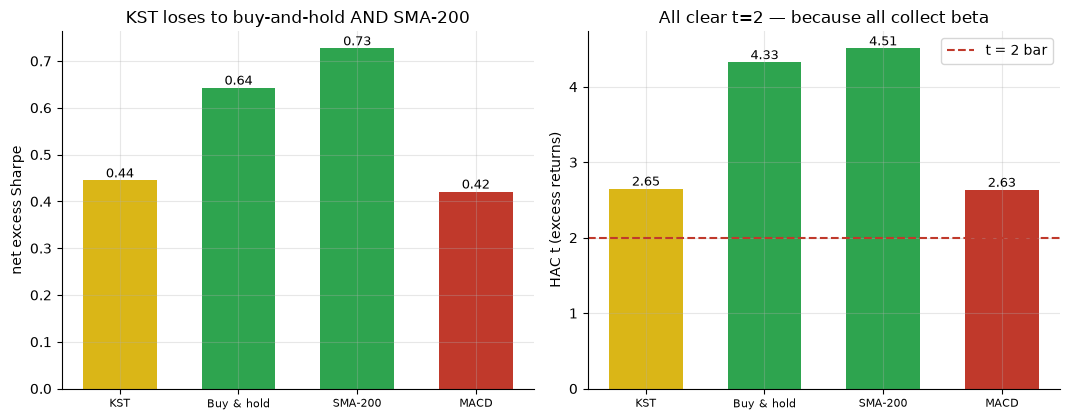

Sharpe: [0.445, 0.643, 0.727, 0.421]
HAC t: [2.65, 4.33, 4.51, 2.63]


In [2]:
names = ['KST', 'Buy & hold', 'SMA-200', 'MACD']
if HAVE_REAL:
    res = st.run_experiment(BARS, cost_bps=R['cost_bps'], n_perm=1)
    sh = [res[a]['sharpe_excess'] for a in ('kst','buy_and_hold','sma200','macd')]
    tt = [res[a]['hac_t'] for a in ('kst','buy_and_hold','sma200','macd')]
else:
    sh = [R['kst'][0], R['bah'][0], R['sma200'][0], R['macd'][0]]
    tt = [R['kst'][3], R['bah'][3], R['sma200'][3], R['macd'][3]]
cols = [AMBER, GREEN, GREEN, RED]
fig, (a1,a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(names, sh, color=cols, width=.62)
for i,v in enumerate(sh): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('net excess Sharpe'); a1.set_title('KST loses to buy-and-hold AND SMA-200')
a1.tick_params(axis='x', labelsize=8)
a2.bar(names, tt, color=cols, width=.62)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,v in enumerate(tt): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('HAC t (excess returns)'); a2.set_title('All clear t=2 — because all collect beta'); a2.legend()
a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print('Sharpe:', [round(s,3) for s in sh]); print('HAC t:', [round(t,2) for t in tt])

> 💡 In plain words: every arm clears HAC *t* = 2 (left bar of buy-and-hold itself is **4.33**) — which is the whole point: **a standalone *t* > 2 just means "it was long a rising market."** On the metric that matters, *risk-adjusted* return, KST (**0.45**) sits **below** buy-and-hold (**0.64**) and well below SMA-200 (**0.73**).

### 4b · Does the timing add information? — the sign-flip permutation

Keep the KST exposure schedule, randomise the *direction* per bar (5,000 fair coins). If the observed Sharpe sits in the right tail, the rule's direction carries real information — **separate** from the question of whether it beats buy-and-hold.

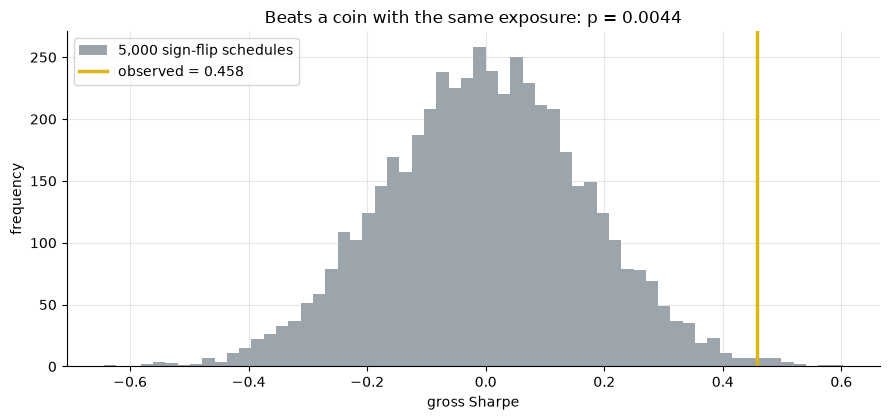

observed 0.458  permutation p = 0.0044


In [3]:
if HAVE_REAL:
    book = st.book_returns(BARS['close'], st.kst_position(BARS['close']), cost_bps=R['cost_bps'])
    pl = st.permutation_pvalue(book, n_draws=5000, seed=426)
    obs, draws, p = pl['obs_sharpe'], pl['draws'], pl['p_value']
else:
    obs, p = R['perm_obs'], R['perm_p']
    rng = np.random.default_rng(426); draws = rng.normal(0.0, 0.18, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='5,000 sign-flip schedules')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed = {obs:.3f}')
ax.set_xlabel('gross Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'Beats a coin with the same exposure: p = {p:.4f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:.3f}  permutation p = {p:.4f}')

> 💡 In plain words: **p = 0.0044** — the KST direction *does* beat a coin. So there is a genuine (if faint) momentum signal. This is what keeps the Signal at **WEAK** and not **NONE** — but "beats a coin" is a far lower bar than "beats holding the market."

### 4c · The decisive tradability test — the KST−buy-and-hold spread

The literal value-add of *trading* the KST over *not* trading: the daily spread (KST net − buy-and-hold net). Its mean and HAC *t* are the honest answer to H₂.

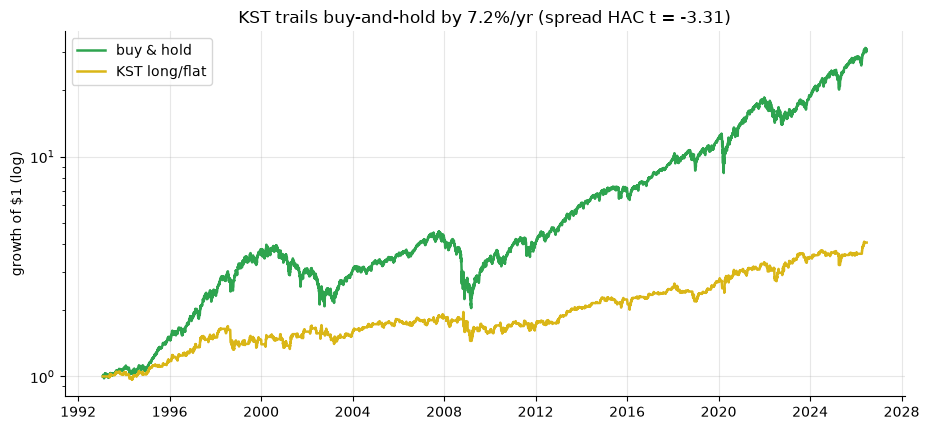

KST - buy&hold spread = -7.16%/yr   HAC t = -3.31


In [4]:
if HAVE_REAL:
    res = st.run_experiment(BARS, cost_bps=R['cost_bps'], n_perm=1)
    kn = res['books']['kst']['net'].to_numpy(); bn = res['books']['buy_and_hold']['net'].to_numpy()
    d = kn - bn
    spread_yr = d.mean()*st.TRADING_DAYS*100; spread_t = st.hac_t(d)
    eq_k = np.cumprod(1+res['books']['kst']['net'].fillna(0).to_numpy())
    eq_b = np.cumprod(1+res['books']['buy_and_hold']['net'].fillna(0).to_numpy())
    idx = BARS.index
else:
    spread_yr, spread_t = R['spread_yr'], R['spread_t']
    idx = np.arange(100); eq_k = np.cumprod(1+np.full(100,0.0002)); eq_b = np.cumprod(1+np.full(100,0.0004))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(idx, eq_b, c=GREEN, lw=1.8, label='buy & hold')
ax.plot(idx, eq_k, c=AMBER, lw=1.8, label='KST long/flat')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'KST trails buy-and-hold by {abs(spread_yr):.1f}%/yr (spread HAC t = {spread_t:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'KST - buy&hold spread = {spread_yr:+.2f}%/yr   HAC t = {spread_t:+.2f}')

> 💡 In plain words: the spread is **-7.2%/yr** at HAC **t = -3.31** — KST *significantly underperforms* buy-and-hold. This is the number that flips Tradability to **MIRAGE**: a standalone *t* of 2.65 looked respectable, but measured as value-add over the benchmark the rule is significantly in the red.

### 4d · Costs and the long/short variant

Left: the cost sweep — KST is below buy-and-hold even at **zero** cost, so costs aren't the killer; the gross timing is simply worse. Right: flipping to **short** below the signal line (the long/short version) is a catastrophe.

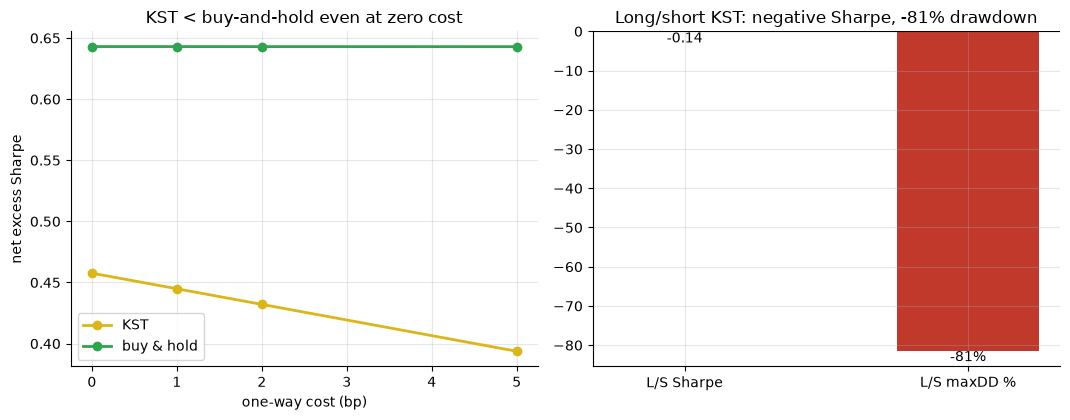

sweep KST: [0.458, 0.445, 0.432, 0.394]
L/S Sharpe -0.139 maxDD 81.4 %


In [5]:
if HAVE_REAL:
    sw = st.cost_sweep(BARS)
    cb = [s['cost_bps'] for s in sw]; ks = [s['kst_sharpe'] for s in sw]; bs = [s['bah_sharpe'] for s in sw]
    rls = st.run_experiment(BARS, cost_bps=R['cost_bps'], allow_short=True, n_perm=1)
    ls_sh = rls['kst']['sharpe_excess']; ls_dd = abs(rls['kst']['maxdd_net'])*100
else:
    cb = [s[0] for s in R['sweep']]; ks = [s[1] for s in R['sweep']]; bs = [s[2] for s in R['sweep']]
    ls_sh = R['ls'][0]; ls_dd = abs(R['ls'][2])
fig, (a1,a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.plot(cb, ks, 'o-', c=AMBER, lw=2, label='KST')
a1.plot(cb, bs, 'o-', c=GREEN, lw=2, label='buy & hold')
a1.set_xlabel('one-way cost (bp)'); a1.set_ylabel('net excess Sharpe')
a1.set_title('KST < buy-and-hold even at zero cost'); a1.legend()
a2.bar(['L/S Sharpe','L/S maxDD %'], [ls_sh, -ls_dd], color=[RED, RED], width=.5)
a2.axhline(0, c='k', lw=.8)
a2.annotate(f'{ls_sh:.2f}',(0,ls_sh),ha='center',va='top',fontsize=10)
a2.annotate(f'{-ls_dd:.0f}%',(1,-ls_dd),ha='center',va='top',fontsize=10)
a2.set_title('Long/short KST: negative Sharpe, -81% drawdown')
plt.tight_layout(); plt.show()
print('sweep KST:', [round(k,3) for k in ks]); print('L/S Sharpe', round(ls_sh,3), 'maxDD', round(ls_dd,1),'%')

> 💡 In plain words: at **0 bp** KST is **0.46** vs buy-and-hold **0.64** — the gap is in the *gross* signal, not costs. And the long/short version (**Sharpe -0.14**, **-81%** drawdown) confirms the short leg has no edge at all: 'sell' is not a tradeable signal, only 'be in cash'.

### 4e · Positive control — the engine *can* reward trend

On a deterministic AR(1) tape we plant **return-trend** and watch the value-add (KST − buy-and-hold spread). With no trend it's strongly negative (timing only sacrifices beta); as trend rises the spread climbs toward zero and KST's Sharpe overtakes buy-and-hold's — proof the harness rewards a real trend when one exists, so the real-tape miss is a true negative.

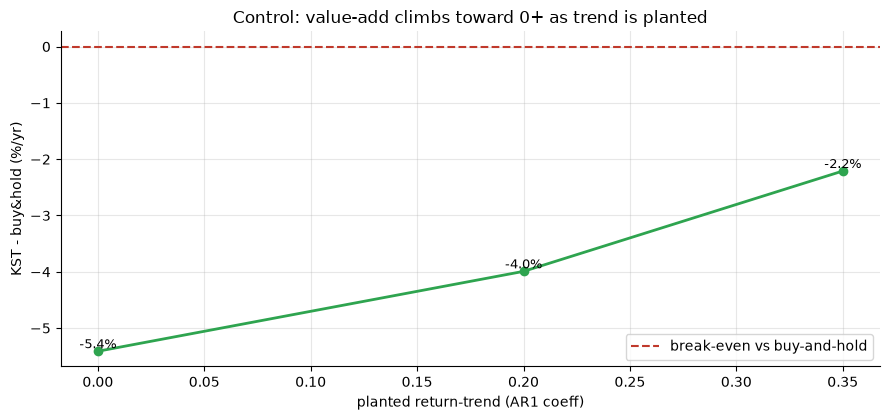

trend=+0.00: KST Sh=0.591 BAH Sh=0.732 spread=-5.41%/yr t=-1.86
trend=+0.20: KST Sh=0.776 BAH Sh=0.775 spread=-3.99%/yr t=-1.14
trend=+0.35: KST Sh=0.973 BAH Sh=0.808 spread=-2.21%/yr t=-0.53


In [6]:
trends = [0.00, 0.20, 0.35]
rows = []
for tr in trends:
    b,_ = data.synthetic_panel(n_days=4000, trend=tr, seed=426)
    r = st.run_experiment(b, cost_bps=R['cost_bps'], n_perm=1)
    kk = r['books']['kst']['net'].to_numpy(); bb = r['books']['buy_and_hold']['net'].to_numpy(); dd = kk-bb
    rows.append((tr, r['kst']['sharpe_excess'], r['buy_and_hold']['sharpe_excess'], dd.mean()*252*100, st.hac_t(dd)))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([r[0] for r in rows], [r[3] for r in rows], 'o-', c=GREEN, lw=2)
ax.axhline(0, c=RED, ls='--', label='break-even vs buy-and-hold')
for r in rows: ax.annotate(f'{r[3]:+.1f}%',(r[0],r[3]),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('planted return-trend (AR1 coeff)'); ax.set_ylabel('KST - buy&hold (%/yr)')
ax.set_title('Control: value-add climbs toward 0+ as trend is planted'); ax.legend()
plt.tight_layout(); plt.show()
for tr,ks_,bs_,sp,t in rows: print(f'trend={tr:+.2f}: KST Sh={ks_:.3f} BAH Sh={bs_:.3f} spread={sp:+.2f}%/yr t={t:+.2f}')

> 💡 In plain words: with **no** trend the spread is **-5.4%/yr** (timing strictly hurts — exactly the real-tape behaviour); at a strong planted trend it lifts to **-2.2%/yr** and KST's Sharpe (**0.97**) overtakes buy-and-hold's (**0.81**). The machinery is faithful — so SPY just doesn't trend persistently enough for KST to add value over simply holding it.

## 5 · The verdict

- **Signal `WEAK`** — the long/flat book clears HAC **t = 2.65** and beats a sign-flip coin (**p = 0.0044**), so there is a faint, *real* directional signal. But it is **beta in disguise**: the value-add over buy-and-hold is significantly negative (spread **t = -3.31**). Genuine pulse, no separable skill — **WEAK**, not REAL.
- **Tradability `MIRAGE`** — net excess Sharpe KST **0.45** < buy-and-hold **0.64** < SMA-200 **0.73**; the rule sheds ~7%/yr vs doing nothing, even at zero cost, and the long/short variant is Sharpe **-0.14** at **-81%** drawdown. Not tradeable as an edge.
- **A sure thing? `BUSTED`** — KST loses the race to **both** buy-and-hold and a one-line SMA-200, and merely ties MACD. The four-ROC complexity buys nothing the simplest trend filter doesn't do better.

## 6 · Could you trade it? — the only thing it does is cut drawdown, and SMA-200 does that better

The one honest selling point: like any long/flat trend filter, KST sits out the worst crashes, so its drawdown is far shallower than buy-and-hold. But that is a *generic* property of being in cash during bear markets — and the plain SMA-200 delivers the same protection while keeping far more upside.

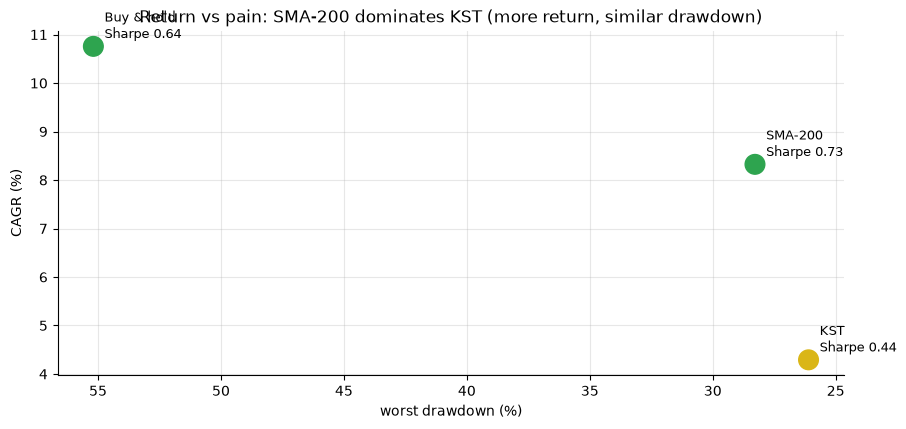

CAGR [4.3, 10.8, 8.3] | maxDD [26.0, 55.0, 28.0]


In [7]:
if HAVE_REAL:
    res = st.run_experiment(BARS, cost_bps=R['cost_bps'], n_perm=1)
    arms = ['kst','buy_and_hold','sma200']
    cg = [res[a]['cagr_net']*100 for a in arms]; dd = [abs(res[a]['maxdd_net'])*100 for a in arms]
    sh = [res[a]['sharpe_excess'] for a in arms]
else:
    cg=[R['kst'][1],R['bah'][1],R['sma200'][1]]; dd=[abs(R['kst'][2]),abs(R['bah'][2]),abs(R['sma200'][2])]; sh=[R['kst'][0],R['bah'][0],R['sma200'][0]]
labels=['KST','Buy & hold','SMA-200']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
sc = ax.scatter(dd, cg, s=[200,200,200], c=[AMBER,GREEN,GREEN], zorder=3)
for l,x,y,s in zip(labels,dd,cg,sh): ax.annotate(f'{l}\nSharpe {s:.2f}',(x,y),textcoords='offset points',xytext=(8,6),fontsize=9)
ax.set_xlabel('worst drawdown (%)'); ax.set_ylabel('CAGR (%)')
ax.set_title('Return vs pain: SMA-200 dominates KST (more return, similar drawdown)')
ax.invert_xaxis(); plt.tight_layout(); plt.show()
print('CAGR', [round(c,1) for c in cg], '| maxDD', [round(d,0) for d in dd])

> 💡 In plain words: KST cuts drawdown to **26%** but pays with a CAGR of only **4.3%**. SMA-200 gets a comparable **28%** drawdown while keeping **8.3%** CAGR — strictly better on both axes than KST. If crash protection is the goal, you don't need the Know Sure Thing; you need one line of code.

## 7 · Going further

- **Parameter robustness.** Eight free knobs invite overfitting. An out-of-sample / walk-forward split of the ROC and SMA lengths is the obvious next test; in-sample tuning will *always* find a winner that fails forward.
- **Asset dependence.** Trend filters earn their keep where trends persist (commodities, FX, single names). The large, mean-reverting US equity index is the *hardest* place for them — re-run on GLD or a momentum-heavy single stock.
- **The generalisable lesson.** A standalone HAC *t* > 2 on a long-only timing rule is **not** evidence of skill — it is the equity risk premium. Always test value-add over buy-and-hold *and* over the simplest benchmark.

*Reproducible core is offline & deterministic; methods and sources in [`docs/references.md`](../docs/references.md), frozen numbers in [`docs/results.md`](../docs/results.md).*